# t-SNE & Anomaly Detection

<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

### Table of Contents:

1. [Introduction](#intro)
2. [Section 1 — t-SNE for Visualization](#section1)
3. [Section 2 — Anomaly Detection](#section2)
4. [Section 3 — Hands-on Lab](#section3)
5. [References](#refs)


<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

<a id="intro"></a>
# Introduction

In the previous notebook, we used **PCA** to reduce a high-dimensional dataset down to a small number of
principal components, and saw that it preserves as much of the data's *global* variance as possible. PCA
is great for compression, but it isn't always the best tool for simply **looking** at data — its
components can mix many original features together in ways that don't reveal cluster structure clearly,
especially when that structure isn't linear.

In this notebook, we introduce **t-SNE**, a dimensionality-reduction technique built specifically for
visualization rather than compression — it focuses on preserving *local* neighborhoods instead of global
variance, which makes it especially good at revealing clusters visually.

We then turn to a different kind of unsupervised problem: **anomaly detection** — finding the data points
that don't fit the pattern of everything else. We'll use **Isolation Forest**, a standard algorithm for
this task, and see how it connects back to the clustering techniques from earlier notebooks (DBSCAN's
"noise" points are, in a sense, anomalies too).


<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

<a id="section1"></a>
# Section 1 : t-SNE for Visualization

## 1.1 What Is t-SNE?

> **t-SNE (t-distributed Stochastic Neighbor Embedding)** is a dimensionality-reduction technique built
> specifically for visualizing high-dimensional data in 2D or 3D.

Unlike PCA, which finds directions of maximum variance across the *whole* dataset, t-SNE focuses on
**local structure**: it tries to keep points that were close together in the original high-dimensional
space close together in the low-dimensional plot, and pushes points that were far apart, apart. This makes
it especially good at revealing clusters visually — including clusters that aren't linearly separable,
which PCA can struggle to show clearly.


## 1.2 How t-SNE Works, At a High Level

1. For every pair of points in the original high-dimensional space, t-SNE computes a probability that
   they would be "neighbors" — nearby points get a high probability, distant points get a low one.
2. It then places all the points randomly in 2D, and computes the same kind of neighbor probabilities in
   that low-dimensional space.
3. It iteratively moves the points around in 2D to make the low-dimensional neighbor probabilities match
   the high-dimensional ones as closely as possible — points that were close in the original space get
   pulled together, and points that were far apart get pushed apart.

The **`perplexity`** parameter roughly controls how many neighbors each point "cares about" when this
neighborhood is computed — think of it as a rough guess at the size of each point's local neighborhood.
Typical values are between 5 and 50; the right value depends on the dataset size and density.


## 1.3 Implementation

```python
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Syntax:
# n_components=2   -> reduce down to 2 dimensions, for plotting
# perplexity=30     -> a rough guess at each point's local neighborhood size
# random_state=42   -> t-SNE is stochastic, so this makes the result reproducible
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X)

# X_tsne is now an (n_samples, 2) array - one 2D point per original data point
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.show()
```

**Syntax explained:**
- `TSNE(n_components=2, perplexity=30, random_state=42)` — creates the t-SNE object. Unlike `PCA`, there's
  no separate `.fit()` then `.transform()` step used in practice — t-SNE doesn't learn a reusable
  transformation the way PCA does.
- `.fit_transform(X)` — runs the full iterative optimization described in 1.2 and returns the final 2D
  coordinates directly. This is the only way t-SNE is normally used — there's no `.transform()` you can
  later apply to new data.
- `c=labels` — colors each point in the scatter plot by a label array (e.g. cluster assignment, or a known
  ground-truth class), so any visual grouping in the plot can be compared against that label.


## 1.4 PCA vs. t-SNE: When to Use Each

| | PCA | t-SNE |
|---|---|---|
| **Preserves** | Global structure / variance | Local neighborhoods |
| **Main use** | Compression *and* visualization | Visualization only |
| **Speed** | Fast | Slow on large data |
| **Axes meaning** | Interpretable directions (principal components) | No meaningful axes — only relative position matters |
| **Reusable on new data?** | Yes (`.transform()`) | No — must be re-run on the full dataset each time |

> **t-SNE is for looking, not for feeding into a model.** Its axes have no real-world meaning, and its
> output changes depending on `perplexity` and `random_state` — use it to *see* whether clusters exist,
> then use PCA (or the original features) for any actual downstream modeling.


<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

<a id="section2"></a>
# Section 2 : Anomaly Detection

## 2.1 What Anomaly Detection Is

> **Anomaly detection** finds data points that differ significantly from the norm — fraud, defective
> products, system failures, or data errors.

It's often treated as an **unsupervised** problem, because anomalies are rare and rarely come pre-labeled
in practice — there usually isn't a large, reliable set of "confirmed fraud" examples to train a
supervised classifier on. Instead, the model learns what "normal" data generally looks like, and flags
whatever deviates meaningfully from that pattern. This is exactly the kind of problem that shows up in a
fraud-detection use case: transactions aren't neatly labeled as fraudulent ahead of time, so the model has
to learn the shape of "normal" behavior and flag outliers to it.


## 2.2 Isolation Forest

**Isolation Forest** is a standard, widely used anomaly-detection algorithm, built on an elegant idea:
**anomalies are easier to isolate than normal points**, because they sit apart from the dense mass of the
data.

**How it works:**
1. The algorithm builds many random decision trees. At each split, it picks a random feature and a random
   split value.
2. Because anomalies sit in sparse, isolated regions of the feature space, it takes very **few** random
   splits to separate an anomaly from everything else.
3. Normal points, sitting in dense regions surrounded by many similar points, take **many more** splits to
   isolate.
4. A point's *average path length* to isolation (across all the trees) becomes its anomaly score — a
   short path means "flagged as anomaly," a long path means "normal."


### Implementation

```python
from sklearn.ensemble import IsolationForest

# Syntax:
# contamination=0.05 -> the estimated FRACTION of the dataset expected to be anomalies (5% here)
# random_state=42     -> for reproducibility, since the algorithm relies on random splits
iso = IsolationForest(contamination=0.05, random_state=42)

# fit_predict() both fits the model AND returns a prediction for every point in one call
preds = iso.fit_predict(X)   # -1 = anomaly, 1 = normal

n_anomalies = (preds == -1).sum()
print(f"Flagged {n_anomalies} anomalies out of {len(X)} points")
```

**Syntax explained:**
- **`contamination`** — your estimate of what fraction of the data is anomalous. This directly controls
  how many points get flagged: a higher value flags more points as anomalies, a lower value flags fewer.
  It's a genuine hyperparameter that needs domain knowledge or experimentation to set well — there's no
  way for the algorithm to "know" the true anomaly rate on its own.
- **`.fit_predict(X)`** — combines fitting the model and generating predictions on the same data in a
  single call; a common pattern for unsupervised methods that aren't meant to be reused on new,
  unseen data the way a supervised classifier would be.
- **Output convention:** `-1` means "flagged as an anomaly," `1` means "considered normal" — this is the
  same `-1`/`1` (rather than `0`/`1`) convention used by several other Scikit-learn anomaly/outlier
  detectors, so it's worth remembering when interpreting results.


## 2.3  Anomaly Detection and Clustering Overlap

This connects back to DBSCAN. Recall that DBSCAN labels certain points as **noise** (assigned to no
cluster at all) when they don't have enough nearby neighbors to belong to any dense region. Those noise
points are, in effect, a simple form of anomaly detection — DBSCAN never markets itself as an
anomaly-detection algorithm, but "point that doesn't belong to any dense cluster" and "point that's easy
to isolate" are two different mathematical routes to a similar idea: **flagging what doesn't fit the
pattern of the rest of the data.**


<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

<a id="section3"></a>
# Section 3 : Hands-on Lab

We'll use the same **Breast Cancer dataset** from the PCA notebook, so the t-SNE plot can be compared
directly against the PCA plot already produced there. Since this notebook is self-contained, we'll first
generate cluster labels with K-Means (standing in for "the clusters from the earlier clustering
notebooks") to color the t-SNE plot by.

## Step 1: Apply t-SNE and Plot, Colored by Cluster


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest

RANDOM_STATE = 42

cancer = load_breast_cancer()
X = cancer.data
y = cancer.target  # 0 = Malignant, 1 = Benign

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Cluster labels standing in for "the clusters from Day 1-2" (K-Means, k=2 to match the two known classes)
kmeans = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

print(f"Dataset shape: {X_scaled.shape}")


Dataset shape: (569, 30)


e:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


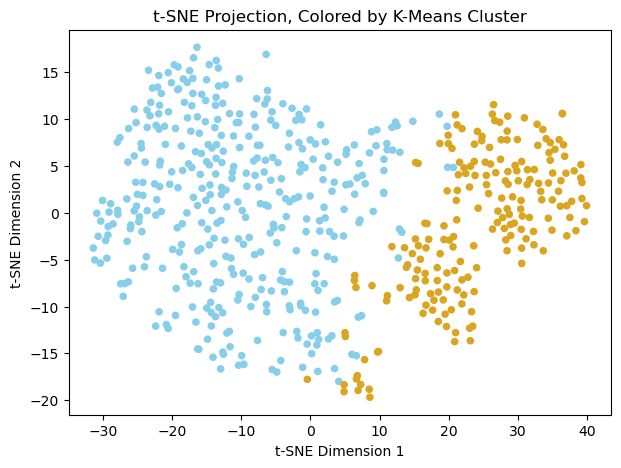

In [8]:
from matplotlib.colors import ListedColormap

# Sky blue and golden yellow
custom_cmap = ListedColormap([
    "#87CEEB",  # Sky blue
    "#DAA520"   # Golden yellow
])

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=RANDOM_STATE
)

X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(7, 5))

plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=cluster_labels,
    cmap=custom_cmap,
    s=20
)

plt.title("t-SNE Projection, Colored by K-Means Cluster")

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")

plt.show()

## Step 2: Compare Against the PCA Plot

For comparison, here's the same data reduced to 2D with PCA instead (as in the previous notebook), colored
the same way.


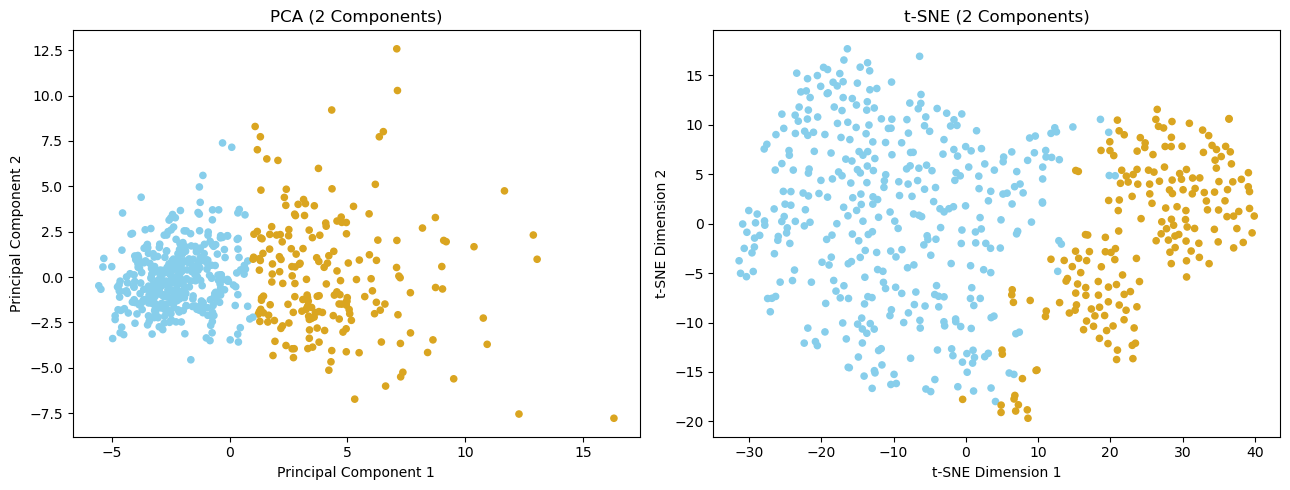

In [9]:
from matplotlib.colors import ListedColormap

# Sky blue and golden yellow
custom_cmap = ListedColormap([
    "#87CEEB",  # Sky blue
    "#DAA520"   # Golden yellow
])

pca_2d = PCA(n_components=2)

X_pca_2d = pca_2d.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=cluster_labels,
    cmap=custom_cmap,
    s=20
)

axes[0].set_title("PCA (2 Components)")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")


axes[1].scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=cluster_labels,
    cmap=custom_cmap,
    s=20
)

axes[1].set_title("t-SNE (2 Components)")
axes[1].set_xlabel("t-SNE Dimension 1")
axes[1].set_ylabel("t-SNE Dimension 2")

plt.tight_layout()
plt.show()

### What each plot shows:

The **PCA plot** shows the two clusters with some overlap. This is because PCA reduces the data based on the directions with the highest overall variance, so it may not clearly separate groups that have a more complex or non-linear structure.

The **t-SNE plot** shows the same two groups as more compact and clearly separated. This is because t-SNE focuses on keeping similar data points close together, which can make local groups easier to see.

In other words, **PCA focuses more on preserving the overall structure and variance of the data**, while **t-SNE focuses more on showing local groups and similarities between nearby points**.


## Step 3: Run Isolation Forest and Report Flagged Anomalies

In [4]:
iso = IsolationForest(contamination=0.05, random_state=RANDOM_STATE)
anomaly_preds = iso.fit_predict(X_scaled)

n_anomalies = (anomaly_preds == -1).sum()
print(f"Flagged {n_anomalies} anomalies out of {len(X_scaled)} points "
      f"({n_anomalies / len(X_scaled):.1%})")

anomaly_scores = iso.decision_function(X_scaled)  # lower score = more anomalous


Flagged 29 anomalies out of 569 points (5.1%)


## Step 4: Inspect Two Flagged Points


In [5]:
anomaly_idx = np.where(anomaly_preds == -1)[0]

# The two most anomalous points (lowest decision_function score)
most_anomalous = anomaly_idx[np.argsort(anomaly_scores[anomaly_idx])[:2]]

feature_names = cancer.feature_names
overall_mean = X.mean(axis=0)
overall_std = X.std(axis=0)

for idx in most_anomalous:
    print(f"\n--- Point index {idx} (class: {'Benign' if y[idx] == 1 else 'Malignant'}) ---")
    z_scores = (X[idx] - overall_mean) / overall_std
    most_unusual_features = np.argsort(-np.abs(z_scores))[:3]
    for f in most_unusual_features:
        print(f"  {feature_names[f]:<25} value={X[idx, f]:.2f}  "
              f"(dataset mean={overall_mean[f]:.2f}, z-score={z_scores[f]:.2f})")



--- Point index 461 (class: Malignant) ---
  area error                value=542.20  (dataset mean=40.34, z-score=11.04)
  perimeter error           value=18.65  (dataset mean=2.87, z-score=7.81)
  radius error              value=2.55  (dataset mean=0.41, z-score=7.73)

--- Point index 122 (class: Malignant) ---
  smoothness error          value=0.02  (dataset mean=0.01, z-score=5.43)
  mean concavity            value=0.43  (dataset mean=0.09, z-score=4.24)
  area error                value=233.00  (dataset mean=40.34, z-score=4.24)


### Interpretation

Both detected points belong to the **Malignant** class. They both have at least one feature that is very far from the average of the dataset, with high z-scores. For example, point 461 has an `area error` with a z-score of around 11, which means that its value is very unusual compared to most of the data.

This is the type of point that Isolation Forest is designed to detect. Because these points are far from the main group of data, they can be isolated more easily using only a few random splits, which gives them a higher chance of being detected as anomalies.

For point 461, the most unusual features are `area error`, `perimeter error`, and `radius error`. These are error measurements, meaning that this tumor has unusually high variation in its measurements across different samples. This does not necessarily mean that the tumor is larger, but that its measurements are more inconsistent or irregular.

Point 122 has a high `smoothness error` and an unusually high `mean concavity`, which may indicate a tumor with a more irregular and non-smooth shape.

In both cases, these anomalies may represent real and unusual biological cases rather than errors in the data. This also shows why anomaly detection is not enough by itself. After detecting an anomaly, we still need to look at the features and understand **why** that point was considered unusual.



<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

<a id="refs"></a>
# References

- t-SNE (Scikit-learn documentation): https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html
- Isolation Forest (Scikit-learn documentation): https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.IsolationForest.html
- How t-SNE Works (visual, interactive explanation): https://distill.pub/2016/misread-tsne/
